# FER2013 — VGG + CBAM + Focal Loss + Face Alignment

**Three improvements over the baseline VGG:**
1. **Face Alignment** — dlib 68-point landmark rotation before training
2. **CBAM Attention** — Channel + Spatial attention gates after each VGG block
3. **Focal Loss** — Replaces cross-entropy + class_weight; focuses gradient on hard/minority examples

---
### Quick-start checklist
- Runtime → Change runtime type → **T4 GPU**
- Upload your `FER2013/` folder to Google Drive at `MyDrive/FER2013/`
- Run cells **top to bottom**

In [ ]:
# ─── Install dlib (~3 min first time; cached after) ───────────────────────
!pip install dlib --quiet

# ─── Download dlib 68-point face-landmark model ───────────────────────────
import os
LANDMARK_DAT = "shape_predictor_68_face_landmarks.dat"

if not os.path.exists(LANDMARK_DAT):
    print("Downloading landmark model ...")
    !wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2
    print("Done.")
else:
    print("Landmark model already present — skipping download.")

# ─── GPU check ────────────────────────────────────────────────────────────
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

Done.
Tesla T4, 15360 MiB


## Cell 2 — Mount Google Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
from datetime import datetime

# ─── Edit ONLY these two lines if your folder is elsewhere ────────────────
DRIVE_ROOT = "/content/drive/MyDrive"
BASE_DIR   = os.path.join(DRIVE_ROOT, "FER2013")
# ──────────────────────────────────────────────────────────────────────────

TRAIN_DIR    = os.path.join(BASE_DIR, "train")
TEST_DIR     = os.path.join(BASE_DIR, "test")
LANDMARK_DAT = "shape_predictor_68_face_landmarks.dat"   # downloaded in Cell 1

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"/content/fer_vgg_cbam_{timestamp}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.isdir(TRAIN_DIR), f"Train dir not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR),  f"Test  dir not found: {TEST_DIR}"
assert os.path.isfile(LANDMARK_DAT), "Landmark .dat missing — re-run Cell 1"

print(f"Train  : {TRAIN_DIR}")
print(f"Test   : {TEST_DIR}")
print(f"Output : {OUTPUT_DIR}")

Mounted at /content/drive
Train  : /content/drive/MyDrive/FER2013/train
Test   : /content/drive/MyDrive/FER2013/test
Output : /content/fer_vgg_cbam_20260315_195220


## Cell 3 — Imports & Global Configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, time, dlib, warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Input,
    BatchNormalization, GlobalAveragePooling2D, GlobalMaxPooling2D,
    Activation, Multiply, Add, Reshape, Concatenate, Lambda
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

# ──────────────────────────────────────────────────────────────────────────
#  HYPERPARAMETERS — edit here only
# ──────────────────────────────────────────────────────────────────────────
IMG_SIZE      = 48
CHANNELS      = 1

BATCH_SIZE    = 64
EPOCHS        = 100

INITIAL_LR    = 3e-4
MIN_LR        = 1e-7

L2_REG        = 5e-5
DROPOUT_CONV  = 0.25
DROPOUT_DENSE = 0.50

PATIENCE      = 15

FOCAL_GAMMA   = 2.0     # 0 → vanilla cross-entropy  |  2 → standard focal
FOCAL_ALPHA   = 0.25    # uniform scalar weight across all classes

EMOTIONS      = ["angry","disgust","fear","happy","neutral","sad","surprise"]
NUM_CLASSES   = len(EMOTIONS)
# ──────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("  FER — VGG + CBAM + FOCAL LOSS + FACE ALIGNMENT")
print("=" * 60)
print(f"  TensorFlow : {tf.__version__}")
print(f"  GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"  Batch size : {BATCH_SIZE}   Initial LR : {INITIAL_LR}")
print(f"  Focal γ    : {FOCAL_GAMMA}            α : {FOCAL_ALPHA}")
print("=" * 60)

  FER — VGG + CBAM + FOCAL LOSS + FACE ALIGNMENT
  TensorFlow : 2.19.0
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  Batch size : 64   Initial LR : 0.0003
  Focal γ    : 2.0            α : 0.25


## Cell 4 — Focal Loss

**Formula:** `FL(p_t) = −α · (1 − p_t)^γ · log(p_t)`

| γ | Effect |
|---|--------|
| 0 | Identical to standard cross-entropy |
| 2 | Strong focus on hard / minority-class examples |

`class_weight` is **removed** from `model.fit()` — Focal Loss handles imbalance implicitly.

In [ ]:
def focal_loss(gamma: float = 2.0, alpha: float = 0.25):
    """
    Multi-class Focal Loss.

    Parameters
    ----------
    gamma : focusing exponent — higher values emphasise hard examples more.
    alpha : uniform scalar weight applied to all classes.

    Returns
    -------
    Keras-compatible loss function (y_true, y_pred) → scalar tensor.
    """
    def loss_fn(y_true, y_pred):
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true   = tf.cast(y_true, tf.float32)

        # Per-sample, per-class cross-entropy
        ce       = -y_true * tf.math.log(y_pred)

        # Focal modulation — p_t is the model's confidence on the correct class
        p_t      = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_wt = tf.pow(1.0 - p_t, gamma)

        loss = alpha * focal_wt * ce
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    loss_fn.__name__ = f"focal_loss_g{gamma}_a{alpha}"
    return loss_fn

print("Focal Loss defined.")

Focal Loss defined.


## Cell 5 — Face Alignment (dlib 68-point landmarks)

**How it works:**
1. dlib detects the face bounding box
2. 68 facial landmarks are predicted
3. Left-eye centroid = mean of landmarks 36–41; Right-eye = 42–47
4. `arctan2` computes tilt angle between the two eye centres
5. `cv2.warpAffine` rotates so the inter-ocular line is horizontal

Falls back silently to the original image if no face is detected (~1–2% of FER2013).

> ⏱ **Expected time:** ~6–10 min for the full 28,000-image training set

In [ ]:
# Load dlib models once — reused for every image
_detector  = dlib.get_frontal_face_detector()
_predictor = dlib.shape_predictor(LANDMARK_DAT)
print("dlib detector and predictor loaded.")


def align_face(img_norm: np.ndarray) -> np.ndarray:
    """
    Rotationally align one face image using eye landmarks.

    Parameters
    ----------
    img_norm : (48,48) or (48,48,1)  float32  [0,1]

    Returns
    -------
    Same shape/dtype — aligned image, or original if alignment fails.
    """
    has_ch  = (img_norm.ndim == 3)
    img_2d  = img_norm.squeeze() if has_ch else img_norm
    img_u8  = (img_2d * 255).clip(0, 255).astype(np.uint8)

    dets = _detector(img_u8, 1)
    if len(dets) == 0:
        return img_norm                         # fallback

    shape     = _predictor(img_u8, dets[0])
    lm        = np.array([[shape.part(i).x, shape.part(i).y]
                           for i in range(68)], dtype=np.float32)

    left_c  = lm[36:42].mean(axis=0)           # left-eye centroid
    right_c = lm[42:48].mean(axis=0)           # right-eye centroid

    angle    = np.degrees(np.arctan2(right_c[1] - left_c[1],
                                     right_c[0] - left_c[0]))
    mid      = ((left_c[0] + right_c[0]) / 2,
                (left_c[1] + right_c[1]) / 2)

    M        = cv2.getRotationMatrix2D(mid, angle, scale=1.0)
    aligned  = cv2.warpAffine(img_u8, M, (IMG_SIZE, IMG_SIZE),
                               flags=cv2.INTER_CUBIC,
                               borderMode=cv2.BORDER_REFLECT_101)

    out = aligned.astype(np.float32) / 255.0
    if has_ch:
        out = np.expand_dims(out, axis=-1)
    return out


def align_dataset(X: np.ndarray, desc: str = "", log_every: int = 2000) -> np.ndarray:
    """Apply align_face to every image in X with progress logging."""
    n, X_out, failed, t0 = len(X), np.empty_like(X), 0, time.time()
    print(f"Aligning {desc} ({n} images) ...")

    for i, img in enumerate(X):
        try:
            X_out[i] = align_face(img)
        except Exception:
            X_out[i] = img
            failed  += 1
        if (i + 1) % log_every == 0:
            ela = time.time() - t0
            eta = ela / (i + 1) * (n - i - 1)
            pct = (i + 1) / n * 100
            print(f"  {i+1:>6}/{n}  [{pct:5.1f}%]  "
                  f"elapsed {ela:5.0f}s  ETA {eta:5.0f}s  failed {failed}")

    print(f"Done — failures: {failed}/{n} ({failed/n*100:.1f}%)  "
          f"time: {time.time()-t0:.0f}s\n")
    return X_out

print("Face alignment functions defined.")

dlib detector and predictor loaded.
Face alignment functions defined.


## Cell 6 — CBAM Attention Block

```
Input feature map (B, H, W, C)
    │
    ▼
Channel Attention          ← "Which feature maps matter?"
  AvgPool(C) + MaxPool(C) → shared MLP → sigmoid gate → multiply
    │
    ▼
Spatial Attention          ← "Where in the image matters?"
  AvgPool(1) + MaxPool(1) → concat → Conv(7×7) → sigmoid map → multiply
    │
    ▼
Attended feature map (B, H, W, C)
```

For FER, the spatial attention map learns to concentrate on diagnostically
discriminative regions — eyes for fear/surprise, mouth for happy/disgust.

In [ ]:
def channel_attention(x: tf.Tensor, ratio: int = 8) -> tf.Tensor:
    """Channel Attention — which feature maps matter?"""
    C = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    fc1 = Dense(C // ratio, activation="relu",
                use_bias=False, kernel_regularizer=l2(L2_REG))
    fc2 = Dense(C, use_bias=False, kernel_regularizer=l2(L2_REG))

    scale = Activation("sigmoid")(Add()([fc2(fc1(avg_pool)),
                                         fc2(fc1(max_pool))]))
    scale = Reshape((1, 1, C))(scale)
    return Multiply()([x, scale])


def spatial_attention(x: tf.Tensor, kernel_size: int = 7) -> tf.Tensor:
    """Spatial Attention — where in the image matters?"""
    # ── FIX: keras.ops work on KerasTensors; tf.* ops do NOT ────────────
    # In Keras 3, tf.reduce_mean/max on a symbolic tensor raises ValueError.
    # keras.ops.mean / keras.ops.max are the correct symbolic-safe replacements.
    avg_pool = keras.ops.mean(x, axis=-1, keepdims=True)   # (B, H, W, 1)
    max_pool = keras.ops.max(x,  axis=-1, keepdims=True)   # (B, H, W, 1)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])     # (B, H, W, 2)
    attn   = Conv2D(1, kernel_size=kernel_size, padding="same",
                    use_bias=False,
                    kernel_regularizer=l2(L2_REG))(concat)
    attn   = Activation("sigmoid")(attn)
    return Multiply()([x, attn])


def cbam_block(x: tf.Tensor, ratio: int = 8, kernel_size: int = 7) -> tf.Tensor:
    """Full CBAM: Channel Attention → Spatial Attention (sequential)."""
    x = channel_attention(x, ratio=ratio)
    x = spatial_attention(x, kernel_size=kernel_size)
    return x

print("CBAM blocks defined (keras.ops, Keras 3 compatible).")

CBAM blocks defined (keras.ops, Keras 3 compatible).


## Cell 7 — Build VGG + CBAM Model

```
Input (48×48×1)
 │
 ├─ Block 1 : 2× Conv(64)  → BN→ReLU → CBAM → MaxPool(2) → Dropout   [48→24]
 ├─ Block 2 : 2× Conv(128) → BN→ReLU → CBAM → MaxPool(2) → Dropout   [24→12]
 ├─ Block 3 : 3× Conv(256) → BN→ReLU → CBAM → MaxPool(2) → Dropout   [12→6]
 ├─ Block 4 : 2× Conv(512) → BN→ReLU → CBAM → MaxPool(2) → Dropout   [6→3]
 │
 ├─ GlobalAveragePooling2D
 ├─ Dense(512) → BN → ReLU → Dropout(0.5)
 ├─ Dense(256) → BN → ReLU → Dropout(0.5)
 └─ Dense(7)   → Softmax
```

In [ ]:
def conv_bn_relu(x, filters, ks=3):
    x = Conv2D(filters, (ks, ks), padding="same",
               kernel_regularizer=l2(L2_REG))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


def build_vgg_cbam_model() -> Model:
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name="input")

    # Block 1 — 64 filters
    x = conv_bn_relu(inp, 64);  x = conv_bn_relu(x, 64)
    x = cbam_block(x)
    x = MaxPooling2D((2, 2))(x);  x = Dropout(DROPOUT_CONV)(x)  # 48→24

    # Block 2 — 128 filters
    x = conv_bn_relu(x, 128);  x = conv_bn_relu(x, 128)
    x = cbam_block(x)
    x = MaxPooling2D((2, 2))(x);  x = Dropout(DROPOUT_CONV)(x)  # 24→12

    # Block 3 — 256 filters
    x = conv_bn_relu(x, 256);  x = conv_bn_relu(x, 256);  x = conv_bn_relu(x, 256)
    x = cbam_block(x)
    x = MaxPooling2D((2, 2))(x);  x = Dropout(DROPOUT_CONV)(x)  # 12→6

    # Block 4 — 512 filters
    x = conv_bn_relu(x, 512);  x = conv_bn_relu(x, 512)
    x = cbam_block(x)
    x = MaxPooling2D((2, 2))(x);  x = Dropout(DROPOUT_CONV)(x)  # 6→3

    # Classifier head
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, kernel_regularizer=l2(L2_REG))(x)
    x = BatchNormalization()(x);  x = Activation("relu")(x)
    x = Dropout(DROPOUT_DENSE)(x)
    x = Dense(256, kernel_regularizer=l2(L2_REG))(x)
    x = BatchNormalization()(x);  x = Activation("relu")(x)
    x = Dropout(DROPOUT_DENSE)(x)
    out = Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

    return Model(inp, out, name="VGG_CBAM_FER")


model = build_vgg_cbam_model()
model.summary()
print(f"\nTrainable params: {model.count_params():,}")

Model: "VGG_CBAM_FER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 48, 48, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        640 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ activation_1[0][… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        512 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        512 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 48,    │          0 │ activation_1[0][… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Mean)         │ (None, 48, 48, 1) │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max (Max)           │ (None, 48, 48, 1) │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 48, 2) │          0 │ mean[0][0],       │
│ (Concatenate)       │                   │            │ max[0][0]       

 Total params: 5,769,295 (22.01 MB)

 Trainable params: 5,763,407 (21.99 MB)

 Non-trainable params: 5,888 (23.00 KB)


Trainable params: 5,769,295


## Cell 8 — Load Data

Loading: /content/drive/MyDrive/FER2013/train
  angry     :  3995 images
  disgust   :   436 images
  fear      :  4097 images
  happy     :  7215 images
  neutral   :  4965 images
  sad       :  4830 images
  surprise  :  3171 images
  Total: 28709 samples  shape (28709, 48, 48, 1)

Loading: /content/drive/MyDrive/FER2013/test
  angry     :   958 images
  disgust   :   111 images
  fear      :  1024 images
  happy     :  1774 images
  neutral   :  1248 images
  sad       :  1247 images
  surprise  :   831 images
  Total: 7193 samples  shape (7193, 48, 48, 1)



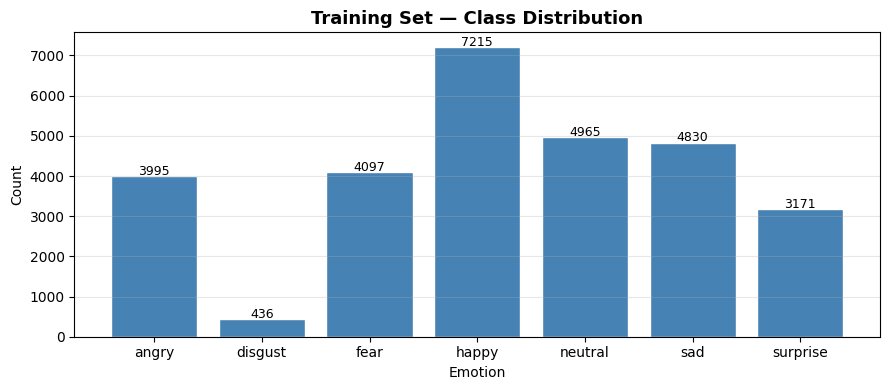

In [ ]:
def load_fer_data(split_dir: str, verbose: bool = True):
    X, y        = [], []
    class_names = sorted(os.listdir(split_dir))
    if verbose:
        print(f"Loading: {split_dir}")
    for label, emotion in enumerate(class_names):
        folder = os.path.join(split_dir, emotion)
        if not os.path.isdir(folder):
            continue
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith((".jpg",".jpeg",".png"))]
        if verbose:
            print(f"  {emotion:<10}: {len(files):>5} images")
        for fname in files:
            try:
                img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
                if img is None: continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img.astype("float32") / 255.0
                img = np.expand_dims(img, axis=-1)
                X.append(img); y.append(label)
            except Exception:
                continue
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    if verbose:
        print(f"  Total: {len(X)} samples  shape {X.shape}\n")
    return X, y, class_names


X_train_raw, y_train, class_names = load_fer_data(TRAIN_DIR)
X_test_raw,  y_test,  _           = load_fer_data(TEST_DIR)

# Class distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
_, counts = np.unique(y_train, return_counts=True)
bars = ax.bar(EMOTIONS, counts, color="steelblue", edgecolor="white")
ax.set_title("Training Set — Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Emotion");  ax.set_ylabel("Count")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, c + 30, str(c),
            ha="center", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=120)
plt.show()

## Cell 9 — Face Alignment Pass

> ⏱ Expect **~6–10 minutes** on the full FER2013 training set (Colab CPU).  
> Alignment is done **once** before training; no overhead per batch during training.

Aligning train (28709 images) ...
    2000/28709  [  7.0%]  elapsed     5s  ETA    66s  failed 0
    4000/28709  [ 13.9%]  elapsed     9s  ETA    56s  failed 0
    6000/28709  [ 20.9%]  elapsed    14s  ETA    53s  failed 0
    8000/28709  [ 27.9%]  elapsed    21s  ETA    55s  failed 0
   10000/28709  [ 34.8%]  elapsed    26s  ETA    48s  failed 0
   12000/28709  [ 41.8%]  elapsed    30s  ETA    42s  failed 0
   14000/28709  [ 48.8%]  elapsed    36s  ETA    38s  failed 0
   16000/28709  [ 55.7%]  elapsed    42s  ETA    33s  failed 0
   18000/28709  [ 62.7%]  elapsed    46s  ETA    27s  failed 0
   20000/28709  [ 69.7%]  elapsed    51s  ETA    22s  failed 0
   22000/28709  [ 76.6%]  elapsed    57s  ETA    17s  failed 0
   24000/28709  [ 83.6%]  elapsed    60s  ETA    12s  failed 0
   26000/28709  [ 90.6%]  elapsed    64s  ETA     7s  failed 0
   28000/28709  [ 97.5%]  elapsed    70s  ETA     2s  failed 0
Done — failures: 0/28709 (0.0%)  time: 72s

Aligning test (7193 images) ...
     500

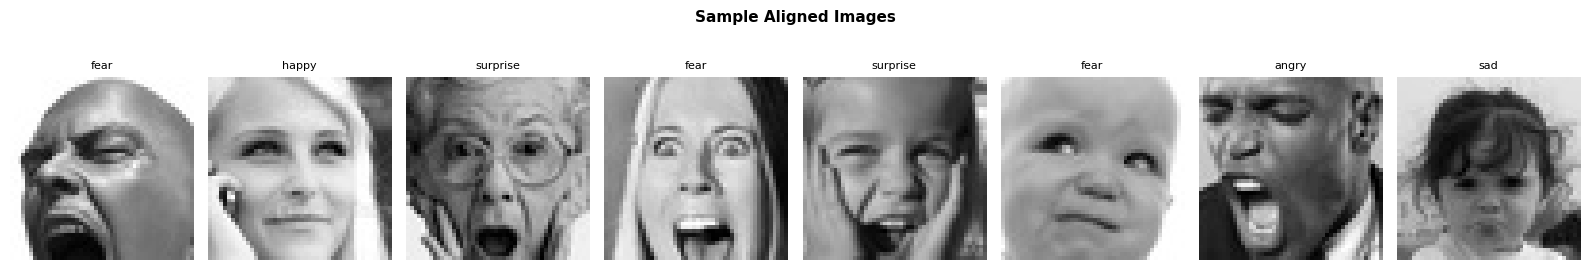

X_train: (28709, 48, 48, 1)  X_test: (7193, 48, 48, 1)


In [ ]:
X_train = align_dataset(X_train_raw, desc="train", log_every=2000)
X_test  = align_dataset(X_test_raw,  desc="test",  log_every=500)

del X_train_raw, X_test_raw    # free RAM

# Quick visual sanity check
n_show  = 8
indices = np.random.choice(len(X_train), n_show, replace=False)

fig, axes = plt.subplots(1, n_show, figsize=(16, 3))
fig.suptitle("Sample Aligned Images", fontsize=11, fontweight="bold")
for ax, idx in zip(axes, indices):
    ax.imshow(X_train[idx].squeeze(), cmap="gray")
    ax.set_title(EMOTIONS[y_train[idx]], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/alignment_sample.png", dpi=100)
plt.show()

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")

## Cell 10 — Compile & Callbacks

In [ ]:
y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode="nearest"
)

def step_decay_schedule(epoch, lr):
    if   epoch < 25: return INITIAL_LR
    elif epoch < 50: return INITIAL_LR * 0.50
    elif epoch < 75: return INITIAL_LR * 0.25
    else:            return INITIAL_LR * 0.10

# Focal Loss replaces categorical_crossentropy AND class_weight
model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
    metrics=["accuracy"]
)

callbacks = [
    LearningRateScheduler(step_decay_schedule, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=PATIENCE,
                  restore_best_weights=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                      patience=8, min_lr=MIN_LR, mode="max", verbose=1),
    ModelCheckpoint(filepath=f"{OUTPUT_DIR}/best_model.keras",
                    monitor="val_accuracy", save_best_only=True,
                    mode="max", verbose=1)
]

print("Model compiled.  Callbacks ready.")

Model compiled.  Callbacks ready.


## Cell 11 — Train

In [ ]:
history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test_cat),
    # NOTE: class_weight intentionally omitted — Focal Loss handles it
    callbacks=callbacks,
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0003.
Epoch 1/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1969 - loss: 0.5930
Epoch 1: val_accuracy improved from None to 0.24677, saving model to /content/fer_vgg_cbam_20260315_195220/best_model.keras

Epoch 1: finished saving model to /content/fer_vgg_cbam_20260315_195220/best_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 91s 133ms/step - accuracy: 0.2134 - loss: 0.5478 - val_accuracy: 0.2468 - val_loss: 0.4745 - learning_rate: 3.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0003.
Epoch 2/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.1562 - loss: 0.5140
Epoch 2: val_accuracy improved from 0.24677 to 0.24746, saving model to /content/fer_vgg_cbam_20260315_195220/best_model.keras

Epoch 2: finished saving model to /content/fer_vgg_cbam_20260315_195220/best_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1562 - loss: 0.5140 - val_accuracy: 0.2475 - val_loss: 0.4

## Cell 12 — Evaluation

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
best_model = load_model(
    f"{OUTPUT_DIR}/best_model.keras",
    compile=False
)
best_model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
    metrics=["accuracy"]
)

test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

y_pred = np.argmax(best_model.predict(X_test), axis=1)

print("\n[ Per-Class Report ]\n")
print(classification_report(y_test, y_pred, target_names=EMOTIONS))

Test Loss     : 0.1701
Test Accuracy : 0.6738  (67.38%)
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step

[ Per-Class Report ]

              precision    recall  f1-score   support

       angry       0.62      0.59      0.61       958
     disgust       0.80      0.60      0.69       111
        fear       0.57      0.39      0.46      1024
       happy       0.88      0.87      0.88      1774
     neutral       0.54      0.79      0.64      1248
         sad       0.59      0.48      0.53      1247
    surprise       0.75      0.81      0.78       831

    accuracy                           0.67      7193
   macro avg       0.68      0.65      0.66      7193
weighted avg       0.68      0.67      0.67      7193



## Cell 13 — Training Curves & Confusion Matrices

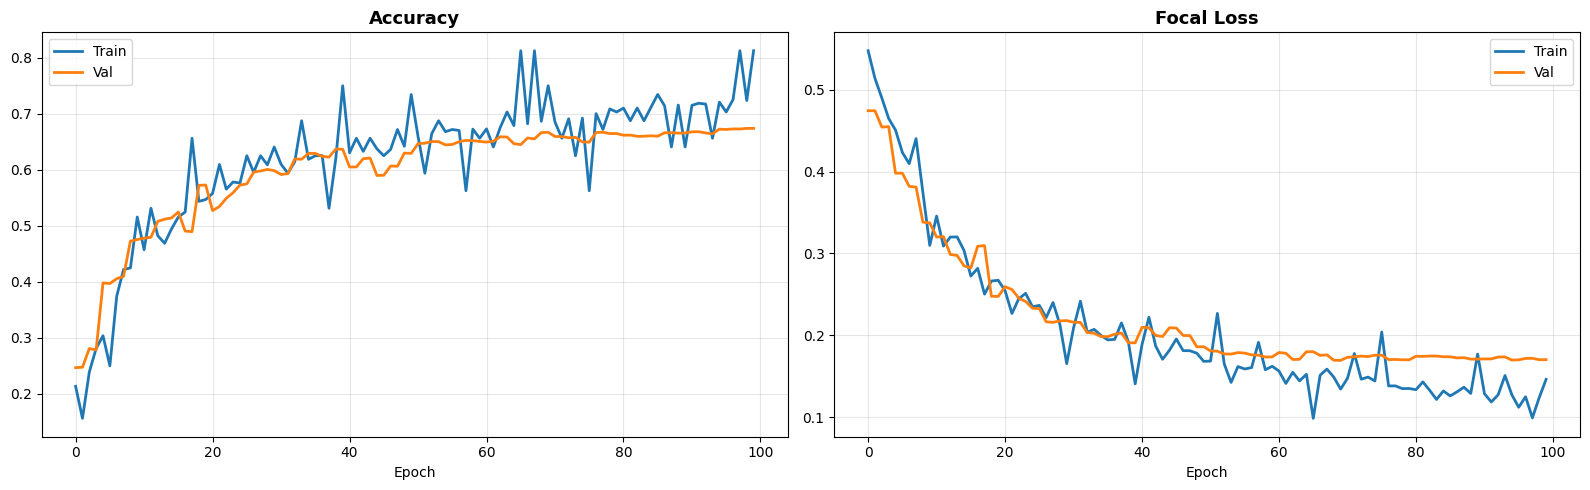

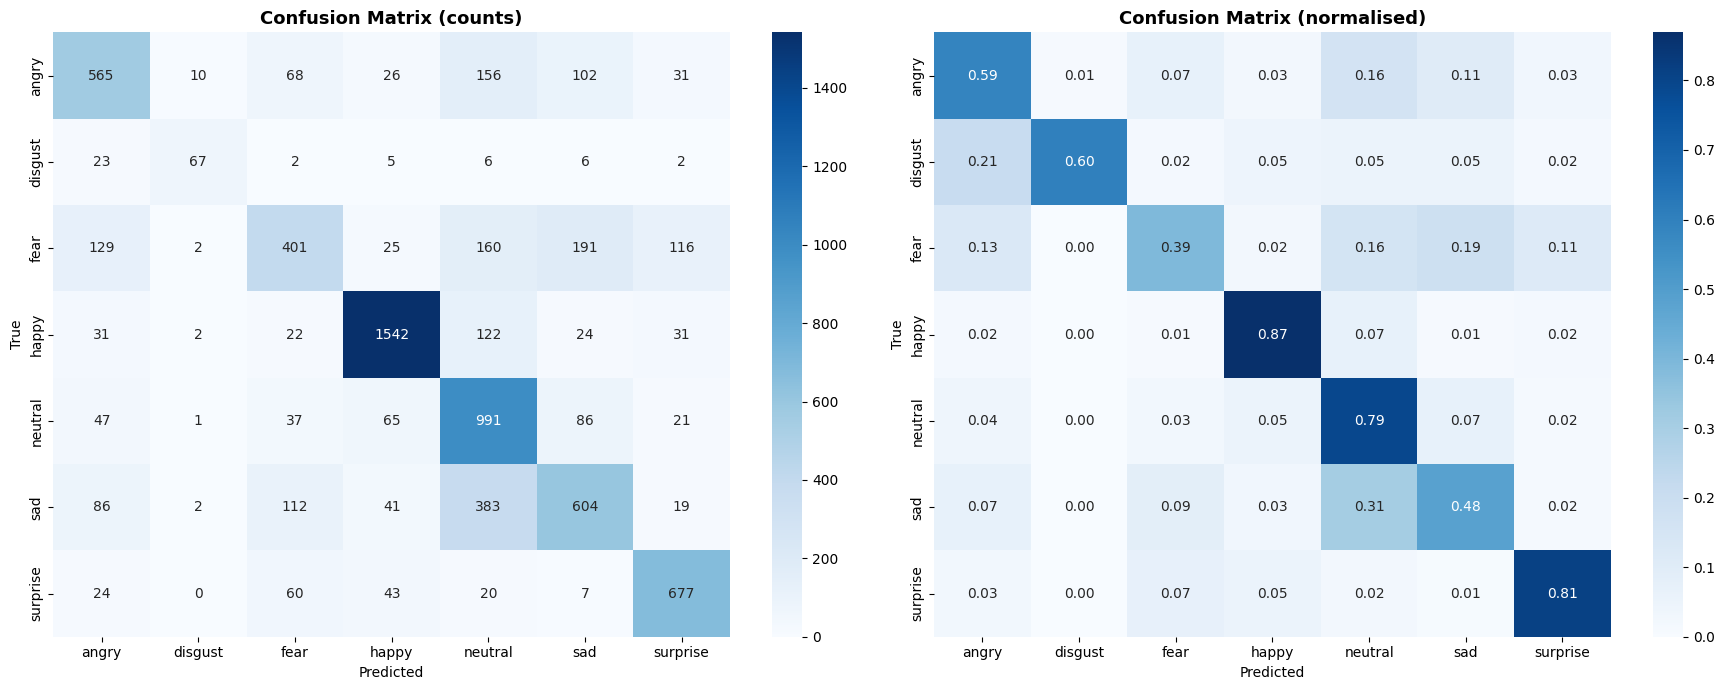

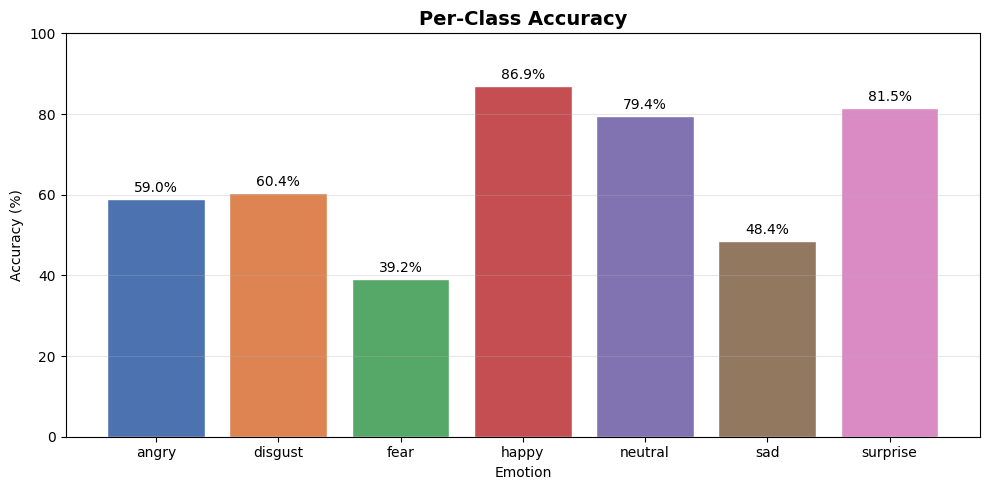

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in zip(axes,
                              [["accuracy","val_accuracy"],["loss","val_loss"]],
                              ["Accuracy","Focal Loss"]):
    ax.plot(history.history[metric[0]], label="Train", lw=2)
    ax.plot(history.history[metric[1]], label="Val",   lw=2)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch");  ax.legend();  ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm], ["d", ".2f"],
        ["Confusion Matrix (counts)", "Confusion Matrix (normalised)"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted");  ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# ── Per-class accuracy bar chart ──────────────────────────────────────────
pca     = cm_norm.diagonal()
palette = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#DA8BC3"]
fig, ax = plt.subplots(figsize=(10, 5))
bars    = ax.bar(EMOTIONS, pca * 100, color=palette, edgecolor="white")
ax.set_ylim(0, 100)
ax.set_title("Per-Class Accuracy", fontsize=14, fontweight="bold")
ax.set_xlabel("Emotion");  ax.set_ylabel("Accuracy (%)")
for bar, a in zip(bars, pca):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{a*100:.1f}%", ha="center", va="bottom", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/per_class_accuracy.png", dpi=150)
plt.show()

## Cell 14 — Save Outputs to Google Drive *(optional)*

Colab's `/content/` is **ephemeral** — it is wiped when the session ends.  
Run this cell to persist the trained model and all plots to Google Drive.

In [ ]:
import shutil

DRIVE_SAVE = os.path.join(DRIVE_ROOT, f"FER_Outputs/fer_vgg_cbam_{timestamp}")
os.makedirs(DRIVE_SAVE, exist_ok=True)

for fname in os.listdir(OUTPUT_DIR):
    src = os.path.join(OUTPUT_DIR, fname)
    dst = os.path.join(DRIVE_SAVE, fname)
    shutil.copy2(src, dst)
    print(f"  Saved: {fname}")

print(f"\nAll outputs saved to Drive:\n  {DRIVE_SAVE}")

  Saved: best_model.keras
  Saved: class_distribution.png
  Saved: training_curves.png
  Saved: per_class_accuracy.png
  Saved: alignment_sample.png
  Saved: confusion_matrix.png

All outputs saved to Drive:
  /content/drive/MyDrive/FER_Outputs/fer_vgg_cbam_20260315_195220


Found 4 spatial attention layers:
  Block 0: 'activation_3'  shape: (None, 48, 48, 1)
  Block 1: 'activation_7'  shape: (None, 24, 24, 1)
  Block 2: 'activation_12'  shape: (None, 12, 12, 1)
  Block 3: 'activation_16'  shape: (None, 6, 6, 1)

Attention extractor built.
Outputs: predictions + 4 spatial attention maps
  Block 0 output shape: (None, 48, 48, 1)
  Block 1 output shape: (None, 24, 24, 1)
  Block 2 output shape: (None, 12, 12, 1)
  Block 3 output shape: (None, 6, 6, 1)
  angry     :  50 samples | attn shapes: [(48, 48), (24, 24), (12, 12), (6, 6)]
  disgust   :  50 samples | attn shapes: [(48, 48), (24, 24), (12, 12), (6, 6)]
  fear      :  50 samples | attn shapes: [(48, 48), (24, 24), (12, 12), (6, 6)]
  happy     :  50 samples | attn shapes: [(48, 48), (24, 24), (12, 12), (6, 6)]
  neutral   :  50 samples | attn shapes: [(48, 48), (24, 24), (12, 12), (6, 6)]
  sad       :  50 samples | attn shapes: [(48, 48), (24, 24), (12, 12), (6, 6)]
  surprise  :  50 samples | attn sha

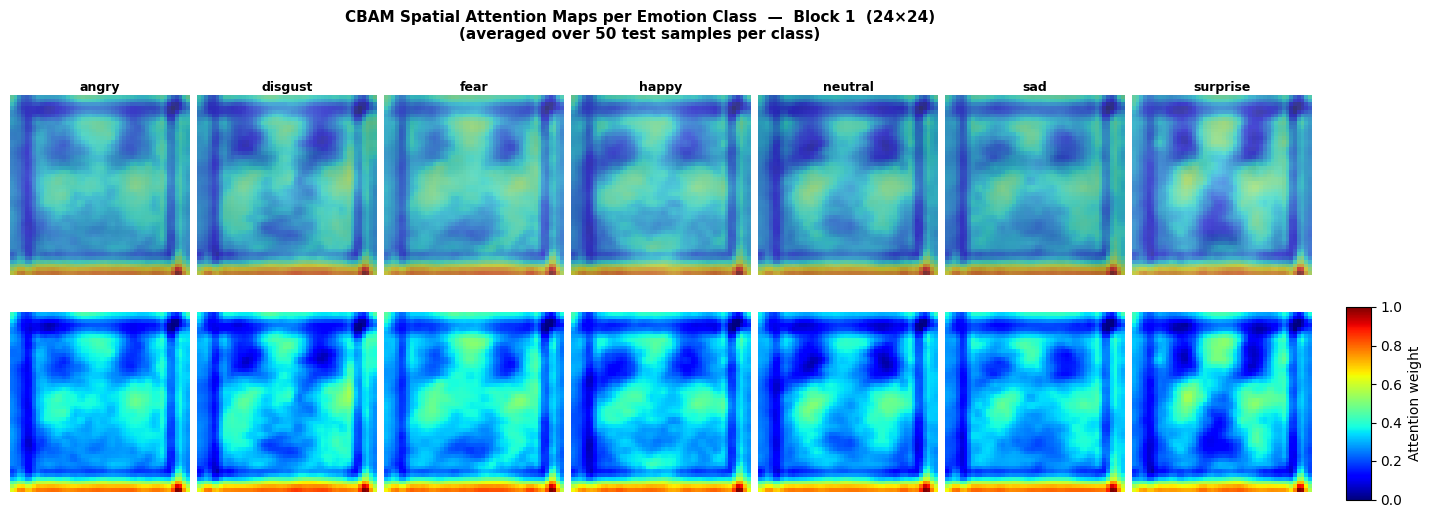

Saved → /content/fer_vgg_cbam_20260315_195220/cbam_attention_maps_block1.png


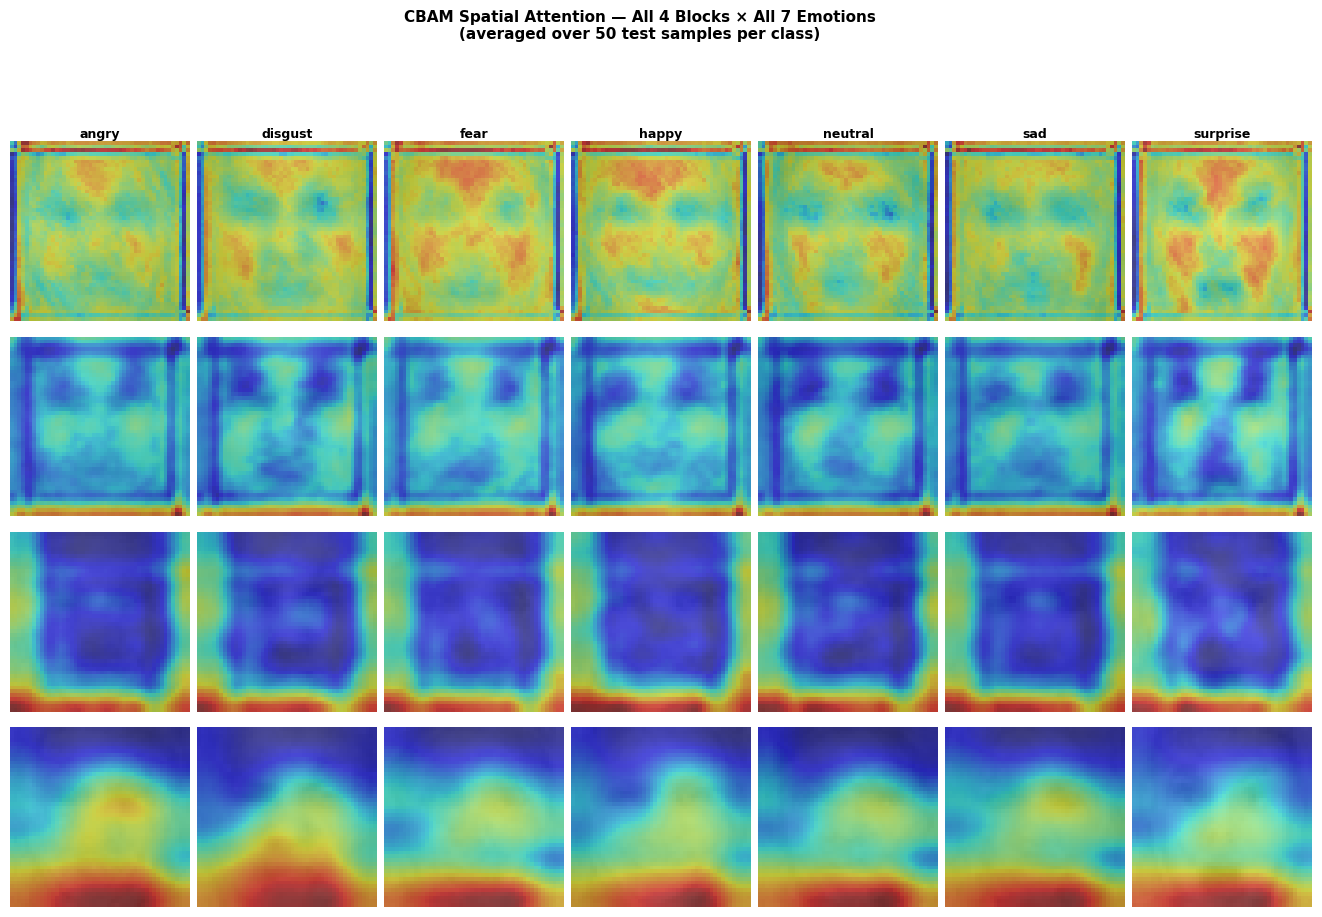

Saved → /content/fer_vgg_cbam_20260315_195220/cbam_attention_all_blocks.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 15 — CBAM SPATIAL ATTENTION MAP VISUALISATION
#
#  What this does:
#    1. Finds the 4 spatial-attention sigmoid layers inside the saved model
#    2. Builds a lightweight sub-model that outputs those 4 maps alongside
#       the normal class predictions
#    3. For each emotion class, runs the sub-model on up to N_SAMPLES images
#       and averages the attention maps across samples
#    4. Upscales each averaged map to 48×48 and alpha-blends it over the
#       mean face image for that class
#    5. Saves a publication-ready 7-panel figure
# ═══════════════════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.models import Model

# ── CONFIG ─────────────────────────────────────────────────────────────────
N_SAMPLES   = 50    # images per class used to average the attention map
BLOCK_TO_VIZ = 1   # which CBAM block to visualise (0=earliest, 3=deepest)
                    # Block 0 (24×24) → low-level texture/edge attention
                    # Block 3 (3×3)   → high-level semantic attention
                    # Recommendation: start with Block 1 or 2 for best FER insight
ALPHA       = 0.55  # heatmap overlay transparency (0=invisible, 1=opaque)
CMAP        = 'jet' # colormap for heatmap; 'hot', 'plasma' also work well

# ── STEP 1: Find the spatial attention sigmoid layers ──────────────────────
#
#  Inside spatial_attention() we have:
#    concat → Conv2D(1, 7×7) → Activation('sigmoid')
#
#  In the saved model these sigmoid activations are named something like
#  "activation_N". We identify them by finding every Activation layer whose
#  output shape is (None, H, W, 1) — exactly what the spatial map produces.

# ── STEP 1: Find spatial attention sigmoid layers ─────────────────────────
#
# Keras 3 removed layer.output_shape as a standalone property.
# We instead inspect layer.output.shape (the actual tensor shape).
# Spatial attention maps have shape (None, H, W, 1) — channel dim == 1.

spatial_attn_layers = []

for layer in best_model.layers:
    if 'activation' not in layer.name.lower():
        continue
    try:
        shape = layer.output.shape   # Keras 3 compatible
    except Exception:
        continue

    # spatial attention maps: rank-4, last dim == 1, not the 1×1 channel squeeze
    # (channel attention produces shape (None, C) which is rank-2 — skip those)
    if len(shape) == 4 and shape[-1] == 1:
        spatial_attn_layers.append(layer)

# sort by spatial resolution: largest H → earliest block
spatial_attn_layers.sort(key=lambda l: l.output.shape[1], reverse=True)

print(f"Found {len(spatial_attn_layers)} spatial attention layers:")
for i, l in enumerate(spatial_attn_layers):
    print(f"  Block {i}: '{l.name}'  shape: {l.output.shape}")

assert len(spatial_attn_layers) == 4, (
    f"Expected 4 spatial attention layers, found {len(spatial_attn_layers)}. "
    "Check that the model was saved after the keras.ops CBAM fix."
)


# ── STEP 2: Build the attention extractor sub-model ────────────────────────

attn_extractor = Model(
    inputs  = best_model.input,
    outputs = [best_model.output] + [l.output for l in spatial_attn_layers],
    name    = "attention_extractor"
)

print("\nAttention extractor built.")
print(f"Outputs: predictions + {len(spatial_attn_layers)} spatial attention maps")

# Quick shape sanity check
for i, out in enumerate(attn_extractor.outputs[1:]):
    print(f"  Block {i} output shape: {out.shape}")


# ── STEP 3: Compute per-class averaged attention maps ──────────────────────

# attn_maps[emotion_idx][block_idx] = averaged map (H, W)
attn_maps   = {}
mean_faces  = {}

for class_idx, emotion in enumerate(EMOTIONS):

    # gather indices for this class in the test set
    indices = np.where(y_test == class_idx)[0]

    # cap to N_SAMPLES, shuffle for variety
    np.random.shuffle(indices)
    indices = indices[:N_SAMPLES]

    batch = X_test[indices]   # (N, 48, 48, 1)

    # run extractor — outputs[0] = softmax probs, outputs[1:] = 4 attn maps
    outputs = attn_extractor.predict(batch, verbose=0)

    preds_batch = outputs[0]                # (N, 7)
    attn_outputs = outputs[1:]              # list of 4 arrays, each (N, H, W, 1)

    # mean face for this class (used as the background)
    mean_faces[class_idx] = batch.mean(axis=0).squeeze()   # (48, 48)

    # average each attention map across samples, squeeze the channel dim
    attn_maps[class_idx] = [
        a.mean(axis=0).squeeze()            # (H, W)
        for a in attn_outputs
    ]

    print(f"  {emotion:<10}: {len(indices):>3} samples | "
          f"attn shapes: {[a.mean(axis=0).squeeze().shape for a in attn_outputs]}")


# ── STEP 4: Upsample & overlay helper ──────────────────────────────────────

def overlay_attention(face_gray: np.ndarray,
                      attn_map: np.ndarray,
                      alpha: float = ALPHA,
                      cmap_name: str = CMAP) -> np.ndarray:
    """
    Alpha-blend an attention map onto a grayscale face image.

    Parameters
    ----------
    face_gray : (48, 48) float32 [0, 1]
    attn_map  : (H, W)   float32 [0, 1]  — any H×W, will be upscaled
    alpha     : heatmap opacity
    cmap_name : matplotlib colormap name

    Returns
    -------
    (48, 48, 3) uint8 — RGB composite
    """
    H, W = face_gray.shape

    # upsample attention to face resolution
    attn_up = cv2.resize(attn_map, (W, H), interpolation=cv2.INTER_CUBIC)
    attn_up = np.clip(attn_up, 0, 1)

    # normalise to [0, 1] per image so low-variance maps still show contrast
    if attn_up.max() > attn_up.min():
        attn_up = (attn_up - attn_up.min()) / (attn_up.max() - attn_up.min())

    # face → 3-channel RGB
    face_rgb = np.stack([face_gray] * 3, axis=-1)              # (H, W, 3)

    # attention map → RGB via colormap
    cmap       = plt.get_cmap(cmap_name)
    heatmap    = cmap(attn_up)[:, :, :3].astype(np.float32)    # (H, W, 3)

    # alpha blend
    composite = (1 - alpha) * face_rgb + alpha * heatmap
    composite = np.clip(composite * 255, 0, 255).astype(np.uint8)

    return composite


# ── STEP 5: Publication-ready 7-panel figure ───────────────────────────────
#
#  Layout: one column per emotion, two rows
#    Row 0: attention overlay (Block BLOCK_TO_VIZ)
#    Row 1: raw normalised attention map (no face) as a clean heatmap

fig, axes = plt.subplots(
    2, NUM_CLASSES,
    figsize=(NUM_CLASSES * 2.4, 5.5),
    gridspec_kw={"hspace": 0.05, "wspace": 0.04}
)

block_label = f"Block {BLOCK_TO_VIZ}  " \
              f"({spatial_attn_layers[BLOCK_TO_VIZ].output.shape[1]}×" \
              f"{spatial_attn_layers[BLOCK_TO_VIZ].output.shape[2]})"

for col, (class_idx, emotion) in enumerate(zip(range(NUM_CLASSES), EMOTIONS)):

    face   = mean_faces[class_idx]                  # (48, 48)
    amap   = attn_maps[class_idx][BLOCK_TO_VIZ]    # (H, W)

    # ── Row 0: overlay ────────────────────────────────────────────────────
    overlay = overlay_attention(face, amap)
    axes[0, col].imshow(overlay)
    axes[0, col].set_title(emotion, fontsize=9, fontweight='bold', pad=3)
    axes[0, col].axis('off')

    # ── Row 1: raw attention map ──────────────────────────────────────────
    amap_norm = (amap - amap.min()) / (amap.max() - amap.min() + 1e-8)
    amap_up   = cv2.resize(amap_norm, (48, 48), interpolation=cv2.INTER_CUBIC)
    axes[1, col].imshow(amap_up, cmap=CMAP, vmin=0, vmax=1)
    axes[1, col].axis('off')

# colourbar
sm  = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(0, 1))
cax = fig.add_axes([0.92, 0.12, 0.015, 0.35])
fig.colorbar(sm, cax=cax, label='Attention weight')

# row labels on left edge
axes[0, 0].set_ylabel("Face + attention",  fontsize=8, rotation=90,
                       labelpad=4, va='center')
axes[1, 0].set_ylabel("Attention map",     fontsize=8, rotation=90,
                       labelpad=4, va='center')

fig.suptitle(
    f"CBAM Spatial Attention Maps per Emotion Class  —  {block_label}\n"
    f"(averaged over {N_SAMPLES} test samples per class)",
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig(
    f"{OUTPUT_DIR}/cbam_attention_maps_block{BLOCK_TO_VIZ}.png",
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print(f"Saved → {OUTPUT_DIR}/cbam_attention_maps_block{BLOCK_TO_VIZ}.png")


# ── STEP 6: All-blocks comparison figure (one row per block) ───────────────
#
#  Shows how attention evolves across depth for each emotion.
#  Useful for the interpretability section of a paper.

fig2, axes2 = plt.subplots(
    4, NUM_CLASSES,
    figsize=(NUM_CLASSES * 2.4, 10),
    gridspec_kw={"hspace": 0.06, "wspace": 0.04}
)

block_sizes = [l.output.shape[1] for l in spatial_attn_layers]

for row in range(4):
    sz = block_sizes[row]
    axes2[row, 0].set_ylabel(
        f"Block {row}  ({sz}×{sz})", fontsize=8, rotation=90,
        labelpad=4, va='center'
    )
    for col, class_idx in enumerate(range(NUM_CLASSES)):
        face = mean_faces[class_idx]
        amap = attn_maps[class_idx][row]
        overlay = overlay_attention(face, amap)
        axes2[row, col].imshow(overlay)
        if row == 0:
            axes2[row, col].set_title(EMOTIONS[class_idx], fontsize=9,
                                      fontweight='bold', pad=3)
        axes2[row, col].axis('off')

fig2.suptitle(
    "CBAM Spatial Attention — All 4 Blocks × All 7 Emotions\n"
    f"(averaged over {N_SAMPLES} test samples per class)",
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig(
    f"{OUTPUT_DIR}/cbam_attention_all_blocks.png",
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print(f"Saved → {OUTPUT_DIR}/cbam_attention_all_blocks.png")